In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/manifest.json
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/README.md
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/manifest.csv
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/manifest.json.sha256
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/manifest.csv.sha256
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/images/brisc2025_test_00560_me_sa_t1.jpg
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/images/brisc2025_test_00949_pi_sa_t1.jpg
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/images/brisc2025_test_00177_gl_sa_t1.jpg
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/images/brisc2025_test_00799_pi_ax_t1.jpg
/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test/images/brisc2025_test_00705_pi_ax_t1.jpg
/kaggle/input/datasets/briscdataset/brisc2

In [2]:
# CELL 1 — Setup & Config (TensorFlow)
# ===================================

import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -------------------------
# GPU Check (Kaggle)
# -------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU available:", gpus[0].name)
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️ No GPU found, running on CPU")

# -------------------------
# Project Configuration
# -------------------------
IMG_SIZE = (256, 256)
IMG_CHANNELS = 3

BATCH_SIZE = 8
EPOCHS = 40
LEARNING_RATE = 3e-4   # TF usually works better slightly higher than PyTorch

# -------------------------
# Class labels (classification head)
# -------------------------
CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'no_tumor']
NUM_CLASSES = len(CLASS_NAMES)

class_to_idx = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print("Class mapping:", class_to_idx)

# -------------------------
# Paths (Kaggle input)
# -------------------------
DATASET_PATH = "/kaggle/input"
WORKING_PATH = "/kaggle/working"

print("Dataset path:", DATASET_PATH)
print("Working path:", WORKING_PATH)


2026-03-06 14:07:21.162289: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772806041.345790      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772806041.396857      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772806041.839975      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772806041.840010      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772806041.840013      24 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: /physical_device:GPU:0
Class mapping: {'glioma': 0, 'meningioma': 1, 'pituitary': 2, 'no_tumor': 3}
Dataset path: /kaggle/input
Working path: /kaggle/working


In [3]:
# =========================================
# CELL 2 — BRISC Segmentation Paths
# =========================================

import os
from glob import glob

BASE_PATH = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task"

TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MASK_DIR  = os.path.join(BASE_PATH, "train/masks")

TEST_IMAGE_DIR  = os.path.join(BASE_PATH, "test/images")
TEST_MASK_DIR   = os.path.join(BASE_PATH, "test/masks")

train_img_paths = sorted(glob(os.path.join(TRAIN_IMAGE_DIR, "*")))
train_mask_paths = sorted(glob(os.path.join(TRAIN_MASK_DIR, "*")))

test_img_paths = sorted(glob(os.path.join(TEST_IMAGE_DIR, "*")))
test_mask_paths = sorted(glob(os.path.join(TEST_MASK_DIR, "*")))

print("Train Images:", len(train_img_paths))
print("Train Masks :", len(train_mask_paths))
print("Test Images :", len(test_img_paths))
print("Test Masks  :", len(test_mask_paths))


Train Images: 3933
Train Masks : 3933
Test Images : 860
Test Masks  : 860


In [4]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 8

def load_image_mask(img_path, mask_path):

    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def create_dataset(img_paths, mask_paths):
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    dataset = dataset.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = create_dataset(train_img_paths, train_mask_paths)
test_ds  = create_dataset(test_img_paths, test_mask_paths)

for x, y in train_ds.take(1):
    print("Image shape:", x.shape)
    print("Mask shape :", y.shape)


I0000 00:00:1772806054.347020      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image shape: (8, 256, 256, 1)
Mask shape : (8, 256, 256, 1)


In [5]:
# CELL 4 — TensorFlow Dataset Pipeline + Visualization
# ====================================================

import os
import pandas as pd

# -----------------------------------------------------
# Dataset Base Path
# -----------------------------------------------------
BASE_PATH = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task"

TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train/images")
TRAIN_MASK_DIR = os.path.join(BASE_PATH, "train/masks")

TEST_IMG_DIR = os.path.join(BASE_PATH, "test/images")
TEST_MASK_DIR = os.path.join(BASE_PATH, "test/masks")

# -----------------------------------------------------
# Collect Train Paths
# -----------------------------------------------------
train_images = sorted(os.listdir(TRAIN_IMG_DIR))
train_masks  = sorted(os.listdir(TRAIN_MASK_DIR))

train_image_paths = [os.path.join(TRAIN_IMG_DIR, f) for f in train_images]
train_mask_paths  = [os.path.join(TRAIN_MASK_DIR, f) for f in train_masks]

train_df = pd.DataFrame({
    "image_path": train_image_paths,
    "mask_path": train_mask_paths,
    "split": "train"
})

# -----------------------------------------------------
# Collect Test Paths
# -----------------------------------------------------
test_images = sorted(os.listdir(TEST_IMG_DIR))
test_masks  = sorted(os.listdir(TEST_MASK_DIR))

test_image_paths = [os.path.join(TEST_IMG_DIR, f) for f in test_images]
test_mask_paths  = [os.path.join(TEST_MASK_DIR, f) for f in test_masks]

test_df = pd.DataFrame({
    "image_path": test_image_paths,
    "mask_path": test_mask_paths,
    "split": "test"
})

# -----------------------------------------------------
# Combine
# -----------------------------------------------------
paired_df = pd.concat([train_df, test_df]).reset_index(drop=True)

print("Train samples:", len(train_df))
print("Test samples :", len(test_df))
print("Total samples:", len(paired_df))


Train samples: 3933
Test samples : 860
Total samples: 4793


In [6]:
# CELL 5: SegNet Model Definition (Encoder–Decoder)
# ====================================================
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Activation
)
from tensorflow.keras.models import Model


def SegNet(input_shape=(256, 256, 1), num_classes=1):   # 🔥 changed 1 → 3

    inputs = Input(shape=input_shape)

    # -------- ENCODER --------
    # Block 1
    x = Conv2D(64, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)

    # Block 2
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)

    # Block 3
    x = Conv2D(256, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)

    # -------- DECODER --------
    # Block 3
    x = UpSampling2D((2,2))(x)
    x = Conv2D(256, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Block 2
    x = UpSampling2D((2,2))(x)
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Block 1
    x = UpSampling2D((2,2))(x)
    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # -------- OUTPUT --------
    outputs = Conv2D(num_classes, (1,1), activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model


# Create model
model = SegNet()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,332,225 (5.08 MB)

 Trainable params: 1,330,433 (5.08 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
# #CELL 6.1
# #===============================

# import tensorflow as tf
# from tensorflow.keras import backend as K

# # -----------------------------
# # Dice Coefficient
# # -----------------------------
# def dice_coefficient(y_true, y_pred, smooth=1e-6):
#     y_true_f = K.flatten(y_true)
#     y_pred_f = K.flatten(y_pred)
#     intersection = K.sum(y_true_f * y_pred_f)
#     return (2. * intersection + smooth) / (
#         K.sum(y_true_f) + K.sum(y_pred_f) + smooth
#     )

# # -----------------------------
# # Dice Loss
# # -----------------------------
# def dice_loss(y_true, y_pred):
#     return 1 - dice_coefficient(y_true, y_pred)

# # -----------------------------
# # Combined BCE + Dice Loss
# # -----------------------------
# def combined_loss(y_true, y_pred):
#     bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
#     d_loss = dice_loss(y_true, y_pred)
#     return 0.5 * bce + 0.5 * d_loss


In [8]:
# CELL 6.2 — Loss Function, Metrics & Model Compilation
# ====================================================

import tensorflow as tf
from tensorflow.keras import backend as K

# -------------------------
# Dice Coefficient
# -------------------------
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        K.sum(y_true_f) + K.sum(y_pred_f) + smooth
    )

# -------------------------
# Dice Loss
# -------------------------
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

# -------------------------
# Combined BCE + Dice Loss
# -------------------------
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dl  = dice_loss(y_true, y_pred)
    return bce + dl

# -------------------------
# Compile the model
# -------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[
        dice_coefficient,
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# -------------------------
# Verify compilation
# -------------------------
print("✅ Model compiled successfully")
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss=combined_loss,
#     metrics=[
#         'accuracy',
#         dice_coefficient,
#         tf.keras.metrics.Precision(),
#         tf.keras.metrics.Recall()
#     ]
# )

# print("✅ Model recompiled with Combined Dice + BCE Loss")


✅ Model compiled successfully


In [9]:
# ===============================
# CELL 7 : Model Training (SAFE)
# ===============================

EPOCHS = 40
BATCH_SIZE = 8

print(" Starting training...")
print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {BATCH_SIZE}")

# -------------------------------
# Callbacks
# -------------------------------

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "segnet_best.keras",
    monitor="val_dice_coefficient",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_dice_coefficient",
    mode="max",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# -------------------------------
# Training
# -------------------------------

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

print(" Training completed successfully")

# -------------------------------
# Save Final Model
# -------------------------------

model.save("segnet_final.keras")
print(" Final model saved as segnet_final.keras")


 Starting training...
Epochs      : 40
Batch size  : 8
Epoch 1/40


I0000 00:00:1772806060.723693      68 service.cc:152] XLA service 0x7a5a8c089520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772806060.723768      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772806061.588467      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/492 ━━━━━━━━━━━━━━━━━━━━ 39s 81ms/step - accuracy: 0.2415 - dice_coefficient: 0.0599 - loss: 1.8669 - precision: 0.0366 - recall: 0.8183   

I0000 00:00:1772806072.335102      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


491/492 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9066 - dice_coefficient: 0.0804 - loss: 1.2444 - precision: 0.1639 - recall: 0.4334

2026-03-06 14:08:29.967915: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 14:08:30.201171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 14:08:30.757787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 14:08:31.013901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9067 - dice_coefficient: 0.0805 - loss: 1.2441 - precision: 0.1641 - recall: 0.4334

2026-03-06 14:08:42.875286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 14:08:43.131118: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_dice_coefficient improved from -inf to 0.05970, saving model to segnet_best.keras
492/492 ━━━━━━━━━━━━━━━━━━━━ 68s 107ms/step - accuracy: 0.9068 - dice_coefficient: 0.0805 - loss: 1.2439 - precision: 0.1642 - recall: 0.4335 - val_accuracy: 0.9688 - val_dice_coefficient: 0.0597 - val_loss: 1.0749 - val_precision: 0.2937 - val_recall: 0.1711
Epoch 2/40
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9678 - dice_coefficient: 0.1527 - loss: 0.9690 - precision: 0.3539 - recall: 0.3383
Epoch 2: val_dice_coefficient improved from 0.05970 to 0.17854, saving model to segnet_best.keras
492/492 ━━━━━━━━━━━━━━━━━━━━ 39s 79ms/step - accuracy: 0.9678 - dice_coefficient: 0.1528 - loss: 0.9688 - precision: 0.3541 - recall: 0.3385 - val_accuracy: 0.9587 - val_dice_coefficient: 0.1785 - val_loss: 0.9428 - val_precision: 0.2806 - val_recall: 0.3823
Epoch 3/40
491/492 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9699 - dice_coefficient: 0.2435 - loss: 0.8428 - precision: 0.4072 - 

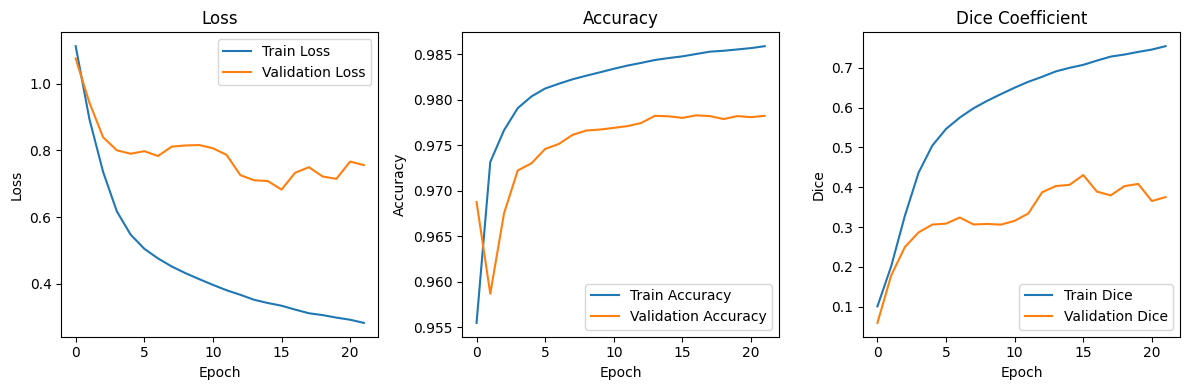

In [10]:
# CELL 8: Plot Training Metrics

import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,3,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Dice Coefficient
plt.subplot(1,3,3)
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Validation Dice')
plt.title('Dice Coefficient')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
import os
print(os.listdir("/kaggle/input"))


['datasets']


In [12]:
import os
print(os.listdir("/kaggle/input/datasets"))

['briscdataset']


In [13]:
import os
print(os.listdir("/kaggle/input/datasets/briscdataset"))

['brisc2025']


In [14]:
import os
print(os.listdir("/kaggle/input/datasets/briscdataset/brisc2025"))

['brisc2025']


In [15]:
import os
print(os.listdir("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"))


['manifest.json', 'README.md', 'segmentation_task', 'classification_task', 'manifest.csv', 'manifest.json.sha256', 'manifest.csv.sha256']


In [16]:
import os

BASE = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task"

for root, dirs, files in os.walk(BASE):
    print("FOLDER:", root)
    print("SUBFOLDERS:", dirs)
    print("FILES:", files[:5])
    print("------")
    break


FOLDER: /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task
SUBFOLDERS: ['test', 'train']
FILES: []
------


In [17]:
import os

TRAIN_PATH = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train"

for root, dirs, files in os.walk(TRAIN_PATH):
    print("FOLDER:", root)
    print("SUBFOLDERS:", dirs)
    print("FILES:", files[:5])
    print("------")
    break


FOLDER: /kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train
SUBFOLDERS: ['images', 'masks']
FILES: []
------
